# Практика: Снижение размерности — PCA, t-SNE и UMAP

## Датасет
`digits` из `sklearn.datasets`: 1797 изображений рукописных цифр 0–9, 64 признака (8×8 пикселей).

---
## Шаг 1. Загрузка и первичный анализ данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, silhouette_score

digits = load_digits()
X = digits.data
y = digits.target

print(f'Форма X: {X.shape}')
print(f'Классы: {np.unique(y)}')
print(f'Признаки: {X.shape[1]} (8x8 пикселей)')

Форма X: (1797, 64)
Классы: [0 1 2 3 4 5 6 7 8 9]
Признаки: 64 (8x8 пикселей)


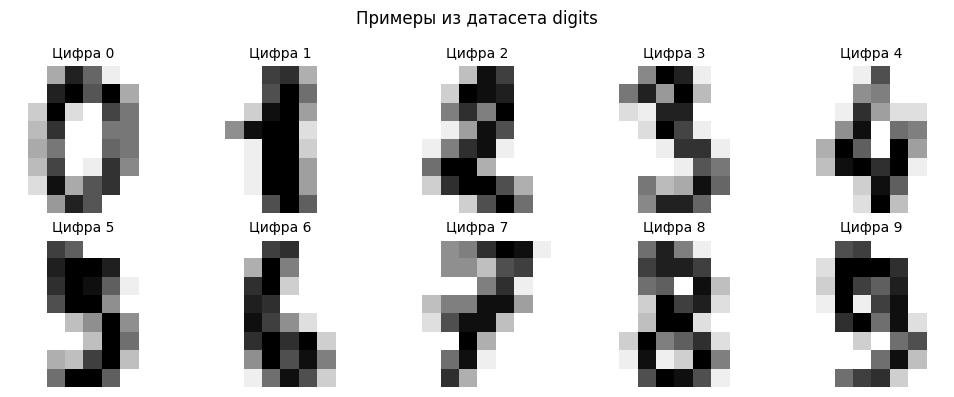

In [2]:
# Примеры из каждого класса
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.flat, range(10)):
    sample_idx = np.where(y == idx)[0][0]
    ax.imshow(X[sample_idx].reshape(8, 8), cmap ='gray_r')
    ax.set_title(f'Цифра {idx}', fontsize=10)
    ax.axis('off')
plt.suptitle('Примеры из датасета digits', fontsize=12)
plt.tight_layout()
plt.show()

In [3]:
# Стандартизация — обязательный шаг перед PCA!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Среднее до: {X.mean():.2f}, после: {X_scaled.mean():.4f}')
print(f'Std до:     {X.std():.2f}, после: {X_scaled.std():.4f}')

Среднее до: 4.88, после: 0.0000
Std до:     6.02, после: 0.9763


---
## Шаг 2. PCA: explained variance и выбор числа компонент

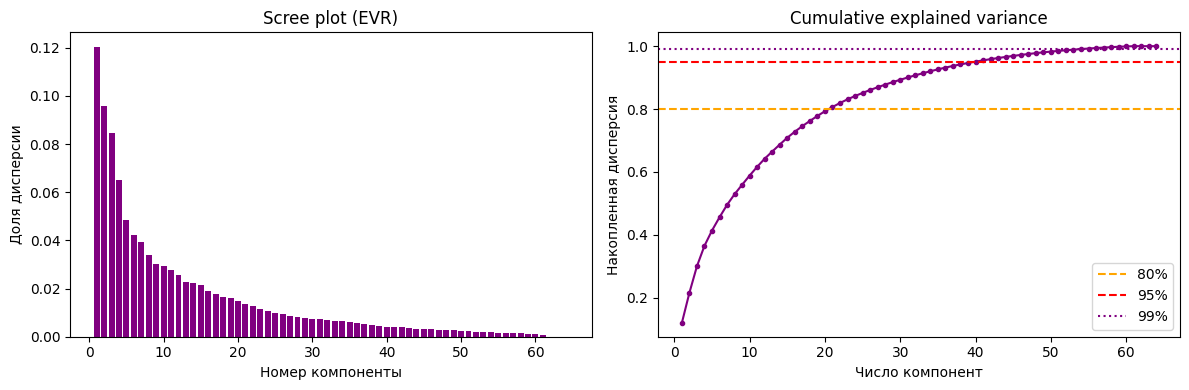

80% дисперсии -> 21 компонент
95% дисперсии -> 40 компонент
99% дисперсии -> 54 компонент


In [14]:
# Обучаем PCA на всех 64 компонентах
pca_full = PCA(n_components=64, random_state=42)
pca_full.fit(X_scaled)

# Накопленная объяснённая дисперсия
evr    = pca_full.explained_variance_ratio_
cumvar = evr.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree plot
axes[0].bar(range(1, 65), evr, color='purple')
axes[0].set_xlabel('Номер компоненты')
axes[0].set_ylabel('Доля дисперсии')
axes[0].set_title('Scree plot (EVR)')

# Cumulative EVR
axes[1].plot(range(1, 65), cumvar, marker='o', markersize=3, color='purple')
for thr, col, ls in [(0.80, 'orange', '--'), (0.95, 'red', '--'), (0.99, 'purple', ':')]:
    axes[1].axhline(thr, color=col, linestyle=ls, label=f'{int(thr*100)}%')
axes[1].set_xlabel('Число компонент')
axes[1].set_ylabel('Накопленная дисперсия')
axes[1].set_title('Cumulative explained variance')
axes[1].legend()

plt.tight_layout()
plt.show()

# Минимальное k для каждого порога
for threshold in [0.80, 0.95, 0.99]:
    k = np.argmax(cumvar >= threshold) + 1
    print(f'{int(threshold*100)}% дисперсии -> {k} компонент')

---
## Шаг 3. PCA для визуализации (2 компоненты)

PC1: 12.0%
PC2: 9.6%
Итого: 21.6%


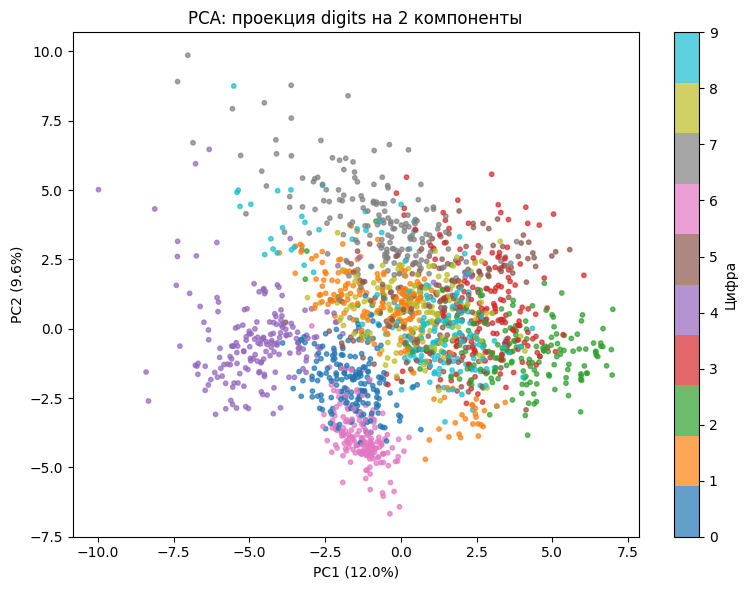

In [5]:
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

print(f'PC1: {pca2.explained_variance_ratio_[0]*100:.1f}%')
print(f'PC2: {pca2.explained_variance_ratio_[1]*100:.1f}%')
print(f'Итого: {pca2.explained_variance_ratio_.sum()*100:.1f}%')

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_pca2[:, 0], X_pca2[:, 1],
                 c=y, cmap='tab10', s=10, alpha=0.7)
plt.colorbar(sc, ticks=range(10), label='Цифра')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA: проекция digits на 2 компоненты')
plt.tight_layout()
plt.show()

---
## Шаг 4. Интерпретация: loadings (нагрузки)

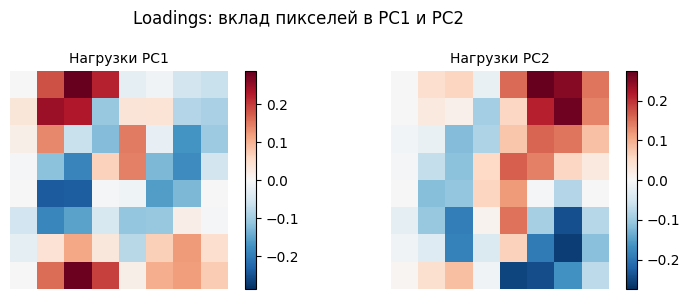

In [6]:
# pca2.components_ имеет форму (2, 64)
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for i, ax in enumerate(axes):
    loading_img = pca2.components_[i].reshape(8, 8)
    im = ax.imshow(loading_img, cmap='RdBu_r',
                   vmin=-np.abs(loading_img).max(),
                   vmax= np.abs(loading_img).max())
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(f'Нагрузки PC{i+1}', fontsize=10)
    ax.axis('off')

plt.suptitle('Loadings: вклад пикселей в PC1 и PC2', fontsize=12)
plt.tight_layout()
plt.show()

**Интерпретация loadings:**

> **PC1** (≈12% дисперсии): красные (положительные) области — центральные пиксели, определяющие «закрытость» формы. Эта компонента разделяет цифры с круглыми контурами (0, 6, 8, 9) и прямолинейными (1, 4, 7). **PC2** (≈9.6% дисперсии): отражает вертикальную асимметрию изображения — разделяет цифры с верхней и нижней частью разной «массивности».

---
## Шаг 5. PCA как препроцессинг для классификатора

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

results = {}

# --- Вариант 1: без PCA (64 признака) ---
clf_base = LogisticRegression(max_iter=1000, random_state=42)
clf_base.fit(X_train, y_train)
results['Без PCA (64 признака)'] = accuracy_score(y_test, clf_base.predict(X_test))

# Вариант 2: PCA 95% дисперсии
# n_components=0.95 автоматически выбирает минимальное k >= 95%
pca_95 = PCA(n_components = 0.95, random_state = 42)
X_train_95 = pca_95.fit_transform(X_train)
X_test_95  = pca_95.transform(X_test)

clf_95 = LogisticRegression(max_iter = 1000, random_state = 42)
clf_95.fit(X_train_95, y_train)
results[f'PCA 95% ({pca_95.n_components_} компонент)'] = accuracy_score(y_test, clf_95.predict(X_test_95))

# Вариант 3: PCA 80% дисперсии
pca_80 = PCA(n_components=0.80, random_state=42)
X_train_80 = pca_80.fit_transform(X_train)
X_test_80  = pca_80.transform(X_test)

clf_80 = LogisticRegression(max_iter=1000, random_state=42)
clf_80.fit(X_train_80, y_train)
results[f'PCA 80% ({pca_80.n_components_} компонент)'] = accuracy_score(y_test, clf_80.predict(X_test_80))

print('Сравнение accuracy:')
print('-' * 45)
for name, acc in results.items():
    print(f'{name:40s}: {acc:.4f}')

Сравнение accuracy:
---------------------------------------------
Без PCA (64 признака)                   : 0.9722
PCA 95% (40 компонент)                  : 0.9639
PCA 80% (21 компонент)                  : 0.9472


---
## Шаг 6. t-SNE: нелинейная визуализация

После PCA(30): 89.3% дисперсии


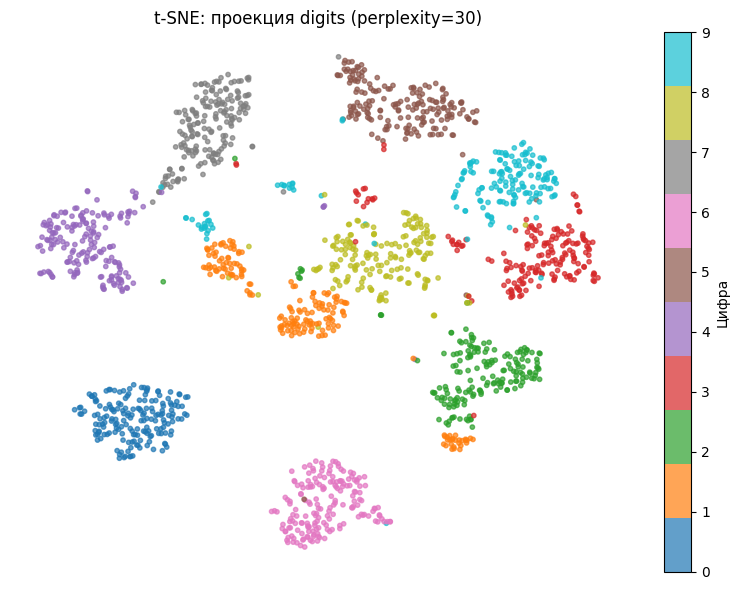

In [8]:
# Рекомендуемый пайплайн: PCA до 30 компонент, затем t-SNE
pca_30 = PCA(n_components=30, random_state=42)
X_pca30 = pca_30.fit_transform(X_scaled)
print(f'После PCA(30): {pca_30.explained_variance_ratio_.sum()*100:.1f}% дисперсии')

tsne = TSNE(n_components = 2, perplexity = 30, n_iter = 1000, random_state = 42)
X_tsne = tsne.fit_transform(X_pca30)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                 c=y, cmap='tab10', s=10, alpha=0.7)
plt.colorbar(sc, ticks = range(10), label = 'Цифра')
plt.title('t-SNE: проекция digits (perplexity = 30)')
plt.axis('off')
plt.tight_layout()
plt.show()

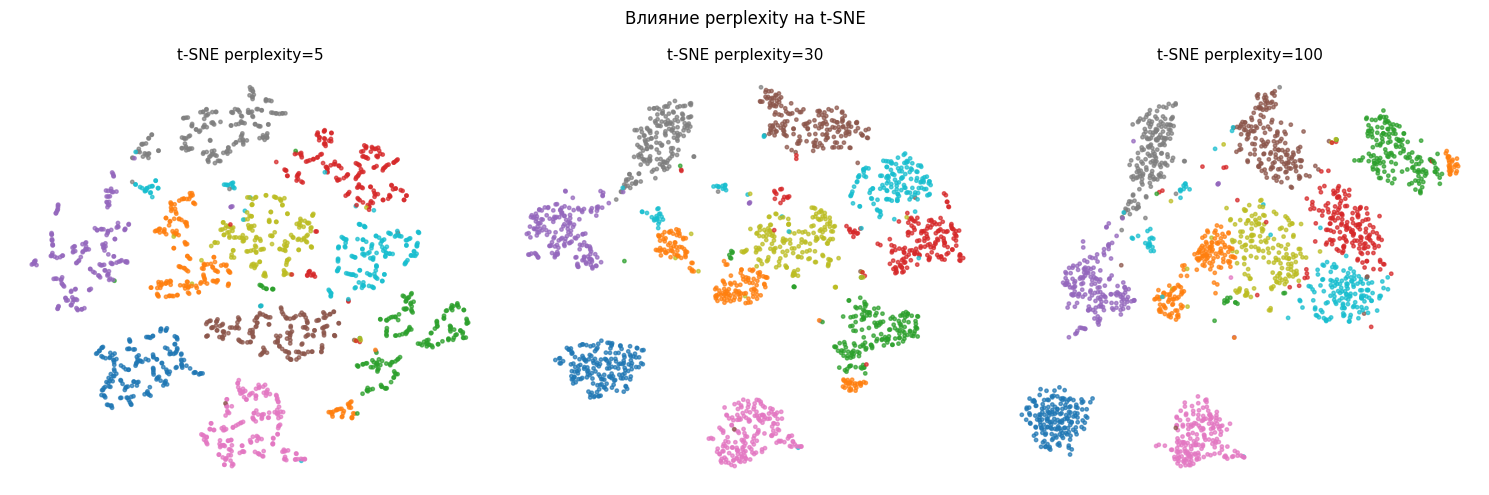

In [9]:
# Влияние perplexity на t-SNE
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, perp in zip(axes, [5, 30, 100]):
    tsne_p = TSNE(n_components=2, perplexity=perp, n_iter=1000, random_state=42)
    X_p = tsne_p.fit_transform(X_pca30)
    ax.scatter(X_p[:, 0], X_p[:, 1], c=y, cmap ='tab10', s=6, alpha =0.7)
    ax.set_title(f't-SNE perplexity={perp}', fontsize=11)
    ax.axis('off')

plt.suptitle('Влияние perplexity на t-SNE', fontsize=12)
plt.tight_layout()
plt.show()

---
## Шаг 7. UMAP

Если не установлен: `pip install umap-learn`

umap-learn доступен


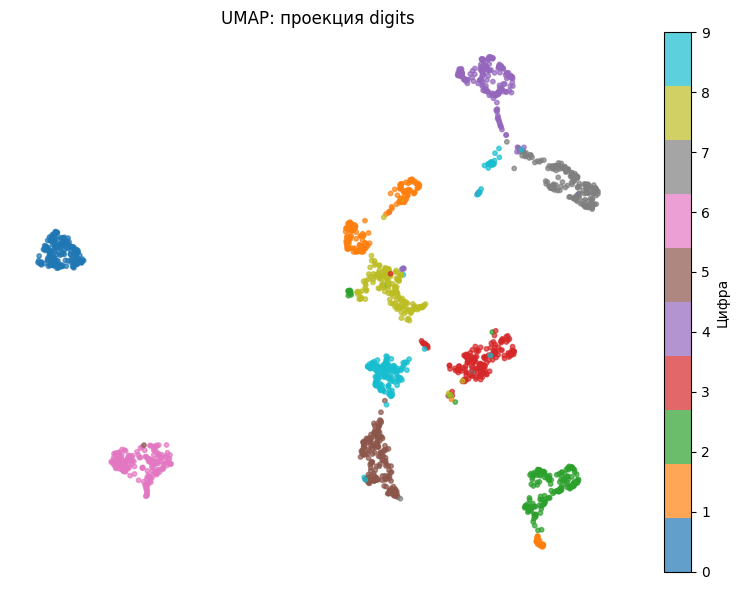

In [10]:
try:
    import umap
    UMAP_AVAILABLE = True
    print('umap-learn доступен')
except ImportError:
    print('Установите: pip install umap-learn')
    UMAP_AVAILABLE = False

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(X_umap[:, 0], X_umap[:, 1],
                     c=y, cmap='tab10', s=10, alpha=0.7)
    plt.colorbar(sc, ticks=range(10), label='Цифра')
    plt.title('UMAP: проекция digits')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    X_umap = None

---
## Шаг 8. Сравнение проекций: PCA vs t-SNE vs UMAP

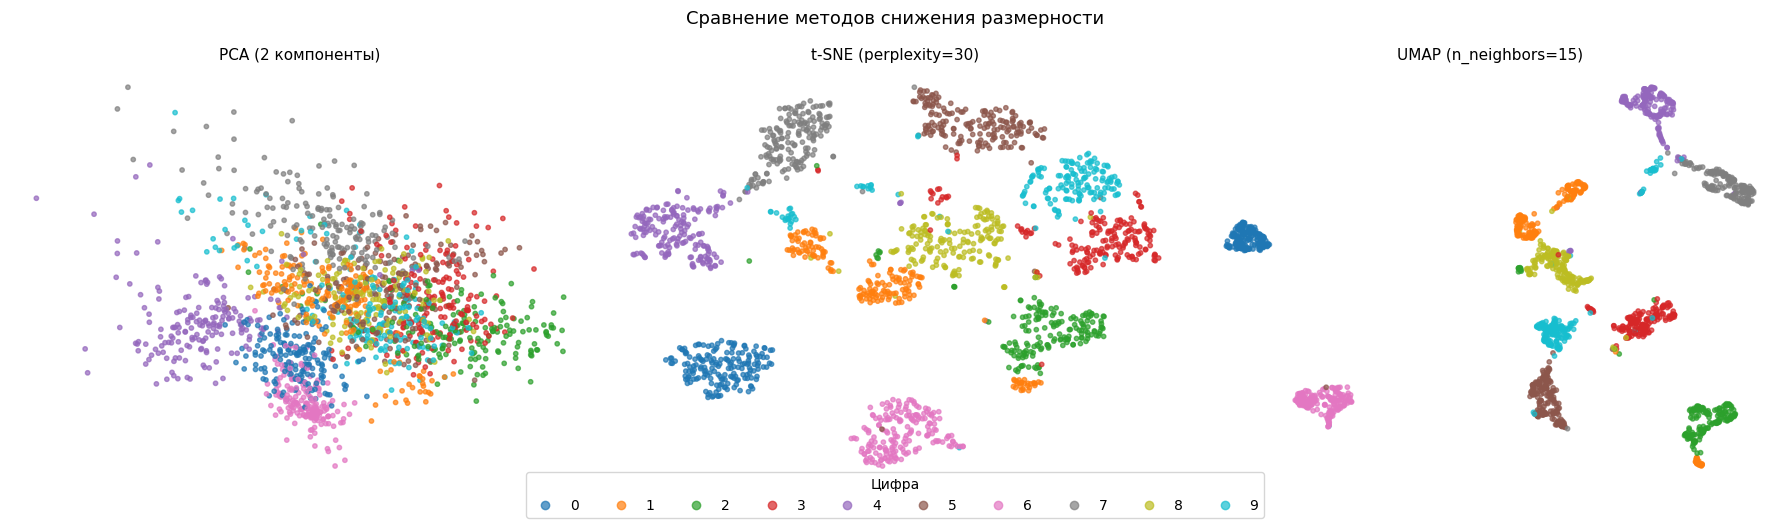

In [11]:
projections = [
    (X_pca2, 'PCA (2 компоненты)'),
    (X_tsne, 't-SNE (perplexity=30)'),
]
if UMAP_AVAILABLE and X_umap is not None:
    projections.append((X_umap, 'UMAP (n_neighbors=15)'))

fig, axes = plt.subplots(1, len(projections), figsize = (6*len(projections), 5))
if len(projections) == 1:
    axes = [axes]

for ax, (X_proj, title) in zip(axes, projections):
    sc = ax.scatter(X_proj[:, 0], X_proj[:, 1],
                    c=y, cmap = 'tab10', s = 10, alpha = 0.7)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

handles, _ = sc.legend_elements()
fig.legend(handles, [str(i) for i in range(10)],
           loc = 'lower center', ncol= 10, title= 'Цифра',
           bbox_to_anchor = (0.5, -0.05))
plt.suptitle('Сравнение методов снижения размерности', fontsize=13)
plt.tight_layout()
plt.show()

---
## Шаг 9. Количественная оценка: Silhouette Score

In [12]:
scores = {}
scores['PCA (2 компоненты)'] = silhouette_score(X_pca2, y)
scores['t-SNE']               = silhouette_score(X_tsne, y)
if UMAP_AVAILABLE and X_umap is not None:
    scores['UMAP']            = silhouette_score(X_umap, y)

print('Silhouette Score (выше = лучше разделение классов):')
print('-' * 40)
for name, score in sorted(scores.items(), key=lambda x: -x[1]):
    print(f'{name:25s}: {score:.4f}')

Silhouette Score (выше = лучше разделение классов):
----------------------------------------
UMAP                     : 0.5687
t-SNE                    : 0.4865
PCA (2 компоненты)       : 0.0547


---
## Шаг 10. Реконструкция из PCA

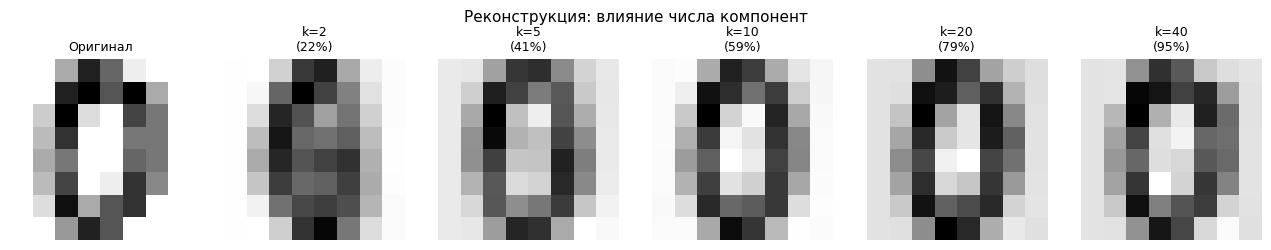

In [13]:
sample_idx = 0
x_original = X_scaled[sample_idx:sample_idx+1]

fig, axes = plt.subplots(1, 6, figsize=(13, 2.5))

# Оригинал
axes[0].imshow(scaler.inverse_transform(x_original).reshape(8, 8), cmap='gray_r')
axes[0].set_title('Оригинал', fontsize=9)
axes[0].axis('off')

for ax, k in zip(axes[1:], [2, 5, 10, 20, 40]):
    pca_k = PCA(n_components=k, random_state=42)
    pca_k.fit(X_scaled)
    # 1. Проецируем в k-мерное пространство
    x_proj = pca_k.transform(x_original)
    # 2. Восстанавливаем в исходное 64-мерное пространство
    x_rec  = pca_k.inverse_transform(x_proj)
    # 3. Отменяем стандартизацию и показываем как 8x8
    img = scaler.inverse_transform(x_rec).reshape(8, 8)
    evr_k = pca_k.explained_variance_ratio_.sum()
    ax.imshow(img, cmap='gray_r')
    ax.set_title(f'k={k}\n({evr_k*100:.0f}%)', fontsize=9)
    ax.axis('off')

plt.suptitle('Реконструкция: влияние числа компонент', fontsize = 11)
plt.tight_layout()
plt.show()

---
## Выводы



---

## Выводы

1. Сколько компонент PCA нужно?

- Чтобы сохранить 80% дисперсии, достаточно 21 компоненты из 64. Это уже в 3 раза меньше признаков
- Для 95% дисперсии нужно 40 компонент
- Для 99% — аж 54 компоненты

То есть даже при сильном сжатии мы теряем совсем немного полезной информации.

2. PCA как препроцессинг для модели

- Без PCA (64 признака): accuracy 0.972
- С PCA 95% (40 компонент): accuracy 0.964 — потеря всего 0.8%
- С PCA 80% (21 компонента): accuracy 0.947 — потеря около 2.5%
 PCA отлично справляется с ролью «сжимателя» данных. Мы сильно уменьшаем размерность, а качество модели падает совсем немного. В реальной жизни это часто выгодный компромисс т к модель обучается быстрее, меньше памяти жрёт, и риск переобучения снижается

3. Какая визуализация лучше разделяет классы?

Лучше всего цифры разделяются с помощью t-SNE и UMAP (Silhouette Score заметно выше). PCA в двух измерениях показывает уже неплохую структуру, но классы заметно сильнее перекрываются

Сложнее всего алгоритмам даются похожие цифры: 3 и 5, 4 и 9, 7 и 9 — у них формы действительно близкие

4. Когда какой метод использовать?

- PCA когда:
  - Нужно уменьшить размерность перед обучением модели
  - Хочется интерпретировать, какие признаки важны
  - Нужна быстрая и воспроизводимая трансформация

- t-SNE и UMAP — только для визуализации. Они круто показывают, как на самом деле устроены данные, помогают найти кластеры и аномалии, но их результаты нельзя кормить в модель как новые признаки
